# RNN con Unrolled Training (Subspace Neural Physics)

AÑADIMOS PRIMERO VELOCIDAD (Ahora estamos calculandola en base a real-pred - anterior MAL)

### 1. El "Impuesto" a la Memoria de la RNN
Tu modelo es una RNN (o GRU/LSTM). Para que la red "sepa" la velocidad sin tenerla como input, tiene que:
1. Usar parte de su **hidden state** para guardar la posición del frame anterior ($t-1$).
2. Realizar una resta interna para comparar $t$ con $t-1$.
3. Usar ese resultado para predecir el siguiente paso.

Si tú le das la velocidad como **input directo**, "liberas" capacidad de la red. En lugar de gastar neuronas en recordar y restar posiciones, la red puede usar toda su capacidad para aprender la física compleja (cómo rebota la tela, cómo se estira, etc.). Estás haciendo que el problema sea más **Markoviano** (el estado actual contiene toda la información necesaria para el futuro).

### 2. La escala y el `fixedDeltaTime`
Mencionaste algo clave:
* En Unity grabas: `(pos - lastPos) / Time.fixedDeltaTime`
* En PyTorch calculas: `real_pos - real_prev_pos`

Aquí hay una diferencia de **escala**. Si en Unity el `fixedDeltaTime` es $0.02$ (50 FPS), la velocidad que guardaste es **50 veces más grande** que el desplazamiento simple.
* Si le das a la red valores de velocidad con una magnitud mayor y más representativa, el gradiente durante el entrenamiento suele ser más estable.
* **Ojo:** Si decides meterla como input, asegúrate de que lo que calculas en el entrenamiento de PyTorch coincida con lo que guardaste en el dataset (es decir, usa el mismo factor de tiempo).

### 3. El "Hint" (Pista) Direccional
La velocidad no es solo un número; es un vector que indica la **dirección del flujo**.

Al dársela como input, le estás diciendo a la red explícitamente: *"Esta es la inercia que trae el punto"*. En el entrenamiento unrolled (rollout), esto es vital porque ayuda a mitigar la **deriva (drift)**. Si la red comete un pequeño error en la posición predicha, pero la velocidad le dice que debe seguir yendo hacia la derecha, el modelo tiene una "segunda opinión" para corregir la trayectoria en el siguiente paso.

### 4. ¿Qué pasa en el Rollout?
Aquí es donde debes tener cuidado. Si decides que la velocidad sea un input:

1.  **En el paso $t=0$:** Le das la posición y velocidad reales del dataset.
2.  **En el paso $t=1$ (predicho):**
    * La red predice `pred_pos_1`.
    * **TÚ debes calcular** la `pred_vel_1` como `(pred_pos_1 - pos_0) / dt`.
    * Esa `pred_vel_1` calculada por ti entra como input para el paso $t=2$.

Esto obliga a la red a ser consistente. Si la red predice una posición "loca", su propio siguiente input de velocidad será "loco", y el `loss_vel` le dará un castigo muy fuerte.

---
## 1. Carga de datos

In [3]:
import pandas as pd
import numpy as np
import torch
import json
import os
from torch.utils.data import Dataset, DataLoader

csv_path = 'data/clothDataset_36_.csv'
df = pd.read_csv(csv_path)

num_vertices = 6

num_features = 7  # x, y, z, vx, vy, vz, sdf

selected_columns = []
for i in range(num_vertices):
    selected_columns.extend([f'x{i}', f'y{i}', f'z{i}', f'vx{i}', f'vy{i}', f'vz{i}', f'sdf{i}'])

df_filtered = df[selected_columns]
data_flat = df_filtered.values
num_frames = data_flat.shape[0]

data_3d = data_flat.reshape((num_frames, num_vertices, num_features))
data_tensor = torch.tensor(data_3d, dtype=torch.float32)

print(f"Frames totales: {num_frames}")
print(f"Tensor shape: {data_tensor.shape}  # [Frames, Vertices, Features]")

Frames totales: 1000
Tensor shape: torch.Size([1000, 6, 7])  # [Frames, Vertices, Features]


---
## 2. Dataset con ventana de rollout

**Diferencia clave:** cada item devuelve `seq_len` frames de historia + `rollout_steps` frames futuros.
El training loop usará esos frames futuros para calcular el loss acumulado.

In [4]:
class ClothUnrolledDataset(Dataset):
    """
    Devuelve:
      - sequence:      [seq_len, Vertices, Features]   <- historia conocida
      - future_frames: [rollout_steps, Vertices, Features] <- W frames futuros reales
    """
    def __init__(self, data_frames, seq_len=5, rollout_steps=8):
        if not isinstance(data_frames, torch.Tensor):
            self.data = torch.tensor(data_frames, dtype=torch.float32)
        else:
            self.data = data_frames
        self.seq_len = seq_len
        self.rollout_steps = rollout_steps

    def __len__(self):
        # Necesitamos seq_len frames de historia + rollout_steps frames futuros
        return len(self.data) - self.seq_len - self.rollout_steps

    def __getitem__(self, idx):
        sequence     = self.data[idx : idx + self.seq_len]                          # [seq_len, V, F]
        future_frames = self.data[idx + self.seq_len :                              # [rollout, V, F]
                                  idx + self.seq_len + self.rollout_steps]
        return sequence, future_frames


SEQ_LEN      = 5   # frames de historia que ve la RNN
ROLLOUT_STEPS = 8  # W del paper: cuántos pasos futuros se predicen durante training
BATCH_SIZE   = 32

dataset = ClothUnrolledDataset(data_tensor, seq_len=SEQ_LEN, rollout_steps=ROLLOUT_STEPS)

# Split cronológico (más honesto para física temporal)
train_size = int(0.8 * len(dataset))
train_dataset = torch.utils.data.Subset(dataset, range(train_size))
test_dataset  = torch.utils.data.Subset(dataset, range(train_size, len(dataset)))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Verificar shapes
seq_b, fut_b = next(iter(train_loader))
print(f"sequence shape:      {seq_b.shape}   # [B, seq_len, V, F]")
print(f"future_frames shape: {fut_b.shape}  # [B, rollout, V, F]")

sequence shape:      torch.Size([32, 5, 6, 7])   # [B, seq_len, V, F]
future_frames shape: torch.Size([32, 8, 6, 7])  # [B, rollout, V, F]


---
## 3. Estadísticas de normalización
*(Se calculan solo sobre train para evitar data leakage)*

In [5]:
all_inputs  = []
all_targets = []

for batch_seq, batch_future in train_loader:
    all_inputs.append(batch_seq.view(-1, num_features))
    # Usamos el primer frame futuro como referencia del delta para normalización
    last_pos   = batch_seq[:, -1, :, 0:3]
    first_future_pos = batch_future[:, 0, :, 0:3]
    delta = first_future_pos - last_pos
    all_targets.append(delta.view(-1, 3))

full_input  = torch.cat(all_inputs, dim=0)
full_target = torch.cat(all_targets, dim=0)

input_mean  = full_input.mean(dim=0)
input_std   = full_input.std(dim=0).clamp(min=1e-8)
target_mean = full_target.mean(dim=0)
target_std  = full_target.std(dim=0).clamp(min=1e-8)

print("input_mean:",  input_mean)
print("target_mean:", target_mean)

norm_data = {
    "mean":        input_mean.tolist(),
    "std":         input_std.tolist(),
    "target_mean": target_mean.tolist(),
    "target_std":  target_std.tolist()
}
with open("cloth_norm_params.json", "w") as f:
    json.dump(norm_data, f)
print("Norm params guardados en cloth_norm_params.json")

input_mean: tensor([-2.9432e-04,  4.7781e-02,  1.4542e-03,  2.0758e-03,  5.8708e-04,
         2.8352e-05,  7.3515e-01])
target_mean: tensor([3.0949e-04, 8.4352e-05, 1.2861e-06])
Norm params guardados en cloth_norm_params.json


---
## 4. Modelo
*(Mismo `FlatRNNClothUnity` de rnn01 — la magia está en el training loop)*

In [6]:
import torch.nn as nn

class FlatRNNClothUnity(nn.Module):
    def __init__(self, num_vertices, num_features, hidden_size, num_outputs=3):
        super().__init__()
        self.num_vertices = num_vertices
        self.num_outputs  = num_outputs
        self.input_size   = num_vertices * num_features
        self.hidden_size  = hidden_size

        self.rnn_cell = nn.RNNCell(
            input_size=self.input_size,
            hidden_size=self.hidden_size,
            nonlinearity='relu'
        )
        self.fc = nn.Linear(self.hidden_size, num_vertices * num_outputs)

    def forward(self, x):
        """
        x: [Batch, Seq_Len, Vertices, Features]
        returns pred_delta: [Batch, Vertices, 3]
        """
        B, T, V, F = x.shape
        x_flat = x.view(B, T, -1)                          # [B, T, V*F]
        h_t = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h_t = self.rnn_cell(x_flat[:, t, :], h_t)
        pred_flat  = self.fc(h_t)                          # [B, V*3]
        pred_delta = pred_flat.view(B, self.num_vertices, self.num_outputs)
        return pred_delta


HIDDEN_SIZE = 128
model = FlatRNNClothUnity(num_vertices=num_vertices,
                          num_features=num_features,
                          hidden_size=HIDDEN_SIZE,
                          num_outputs=3)

total_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros totales: {total_params:,}")

Parámetros totales: 24,338


---
## 5. Unrolled Training Loop  ← La diferencia principal

### Lógica del rollout (inspirada en Algorithm 1 del paper)

```python
# Pseudocódigo del paper adaptado a nuestra arquitectura:
for k in range(W):                          # W = ROLLOUT_STEPS
    pred_delta = model(window_norm)         # predice delta del siguiente frame
    pred_pos   = last_pos + denorm(pred_delta)  # reconstruye posición absoluta
    
    # Autocorrección: meter la predicción como input del siguiente paso
    window = roll(window, pred_pos)         # desplaza ventana temporal
    
    # Acumular loss en posición Y velocidad (como el paper)
    loss += L1(pred_pos, real_pos_k) + L1(pred_vel, real_vel_k)

loss /= W
loss.backward()   # gradiente fluye a través de TODOS los pasos
```

El gradiente se propaga hacia atrás a través de toda la cadena de rollout (BPTT),
penalizando predicciones que desestabilizan los pasos futuros.

In [ ]:
criterion   = nn.L1Loss()
optimizer   = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler   = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)

EPOCHS      = 500
NOISE_SIGMA = 0.02   # ruido en los 2 frames iniciales (como el paper)
VEL_WEIGHT  = 1.0    # peso del loss de velocidad (Lvel en el paper)

# ─────────────────────────────────────────────────────────────────
# Helpers de normalización / desnormalización
# ─────────────────────────────────────────────────────────────────
def norm_input(x):
    """ x: [..., F=4] """
    return (x - input_mean) / input_std

def denorm_delta(d):
    """ d: [..., 3] """
    return d * target_std + target_mean

def norm_delta(d):
    return (d - target_mean) / target_std

# ─────────────────────────────────────────────────────────────────
# Función de un rollout completo (usada en train y eval)
# ─────────────────────────────────────────────────────────────────
def run_rollout(batch_seq, batch_future, add_noise=False):
    """
    batch_seq:    [B, seq_len, V, F]   — historia inicial
    batch_future: [B, rollout, V, F]   — frames reales futuros
    
    Retorna el loss acumulado (posición + velocidad) sobre los W pasos.
    """
    B, W, V, F = batch_future.shape
    
    # Ventana deslizante de posiciones absolutas  [B, seq_len, V, F]
    # Hacemos clone para no modificar el tensor original (lo necesita pytorch para el backward)
    window = batch_seq.clone()   # [B, seq_len, V, F]

    # Ruido inicial en los 2 últimos frames de la historia (Paper §5.4)
    if add_noise:
        noise = torch.randn_like(window[:, -2:, :, :]) * NOISE_SIGMA
        window[:, -2:, :, :] = window[:, -2:, :, :] + noise

    total_loss = torch.tensor(0.0, device=batch_seq.device)

    prev_pred_pos = window[:, -1, :, 0:3]  # posición del frame t-1 (para vel)

    for k in range(W):
        # ── Forward ────────────────────────────────────────────────
        window_norm = norm_input(window)           # [B, seq_len, V, F]
        pred_delta_norm = model(window_norm)       # [B, V, 3]

        last_pos = window[:, -1, :, 0:3]          # posición del último frame conocido
        pred_delta_real = denorm_delta(pred_delta_norm)   # [B, V, 3]
        pred_pos = last_pos + pred_delta_real      # posición predicha [B, V, 3]

        # ── Targets reales ─────────────────────────────────────────
        real_pos = batch_future[:, k, :, 0:3]     # [B, V, 3]
        real_prev_pos = (
            batch_future[:, k-1, :, 0:3] if k > 0
            else batch_seq[:, -1, :, 0:3]
        )

        # ── Loss posición ──────────────────────────────────────────
        real_delta      = real_pos - last_pos
        real_delta_norm = norm_delta(real_delta)
        loss_pos = criterion(pred_delta_norm, real_delta_norm)

        # ── Loss velocidad (Paper §5.4: Lvel) ──────────────────────
        # velocidad predicha vs real (diferencia de posiciones consecutivas)
        pred_vel = pred_pos - prev_pred_pos        # [B, V, 3]
        real_vel = batch_future[:, k, :, 3:6]       # [B, V, 3]
        # normalizamos con target_std para escalar consistente
        loss_vel = criterion(
            pred_vel / target_std.clamp(min=1e-8),
            real_vel / target_std.clamp(min=1e-8)
        )

        total_loss = total_loss + loss_pos + VEL_WEIGHT * loss_vel

        # ── Feedback: pred_pos → nuevo último frame de la ventana ──
        # Construimos el nuevo frame predicho con x,y,z + sdf del real
        # (el sdf no lo predecimos, usamos el real como aprox)
        new_frame = window[:, -1, :, :].clone()   # copia del último frame
        new_frame[:, :, 0:3] = pred_pos.detach() if not model.training else pred_pos
        # Desplazamos la ventana: quitamos el frame más antiguo, añadimos la predicción
        window = torch.cat([window[:, 1:, :, :], new_frame.unsqueeze(1)], dim=1)

        prev_pred_pos = pred_pos

    return total_loss / W


# ─────────────────────────────────────────────────────────────────
# Bucle de entrenamiento
# ─────────────────────────────────────────────────────────────────
history = {'train': [], 'test': [], 'vertex_error': []}

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for batch_seq, batch_future in train_loader:
        batch_seq    = batch_seq.float()
        batch_future = batch_future.float()

        loss = run_rollout(batch_seq, batch_future, add_noise=True)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    scheduler.step()
    avg_train = train_loss / len(train_loader)

    # ── TEST ─────────────────────────────────────────────────────
    model.eval()
    test_loss  = 0.0
    total_err  = 0.0
    total_verts = 0

    all_pred_pos   = []
    all_target_pos = []

    with torch.no_grad():
        for batch_seq, batch_future in test_loader:
            batch_seq    = batch_seq.float()
            batch_future = batch_future.float()

            loss = run_rollout(batch_seq, batch_future, add_noise=False)
            test_loss += loss.item()

            # Para métricas, evaluamos solo el primer frame predicho
            window_norm  = norm_input(batch_seq)
            pred_dn      = model(window_norm)
            last_pos     = batch_seq[:, -1, :, 0:3]
            pred_pos     = last_pos + denorm_delta(pred_dn)
            target_pos   = batch_future[:, 0, :, 0:3]

            all_pred_pos.append(pred_pos.cpu().numpy())
            all_target_pos.append(target_pos.cpu().numpy())

            distances = torch.norm(pred_pos - target_pos, dim=-1)
            total_err   += distances.sum().item()
            total_verts += distances.numel()

    avg_test     = test_loss  / len(test_loader)
    avg_vert_err = total_err  / total_verts


    history['train'].append(avg_train)
    history['test'].append(avg_test)
    history['vertex_error'].append(avg_vert_err)

    preds_pos_np   = np.concatenate(all_pred_pos,   axis=0)
    targets_pos_np = np.concatenate(all_target_pos, axis=0)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train: {avg_train:.6f} | "
              f"Test: {avg_test:.6f} | VertErr: {avg_vert_err:.6f}")

print("\nEntrenamiento completado.")

Epoch 001 | Train: 7.867227 | Test: 7.302232 | VertErr: 0.060617
Epoch 010 | Train: 7.162079 | Test: 6.570499 | VertErr: 0.042899
Epoch 020 | Train: 6.952625 | Test: 6.387273 | VertErr: 0.037998
Epoch 030 | Train: 6.847173 | Test: 6.255051 | VertErr: 0.033799
Epoch 040 | Train: 6.729482 | Test: 6.165834 | VertErr: 0.030319
Epoch 050 | Train: 6.663696 | Test: 6.091549 | VertErr: 0.027714
Epoch 060 | Train: 6.614575 | Test: 6.036811 | VertErr: 0.026002
Epoch 070 | Train: 6.560754 | Test: 5.996537 | VertErr: 0.024416
Epoch 080 | Train: 6.533826 | Test: 5.957785 | VertErr: 0.024070
Epoch 090 | Train: 6.510985 | Test: 5.928761 | VertErr: 0.023679
Epoch 100 | Train: 6.473226 | Test: 5.899285 | VertErr: 0.023308
Epoch 110 | Train: 6.445877 | Test: 5.872802 | VertErr: 0.022727
Epoch 120 | Train: 6.415155 | Test: 5.846054 | VertErr: 0.022201
Epoch 130 | Train: 6.415821 | Test: 5.834394 | VertErr: 0.022135
Epoch 140 | Train: 6.390760 | Test: 5.816718 | VertErr: 0.022206
Epoch 150 | Train: 6.3553

---
## 6. Visualización de resultados

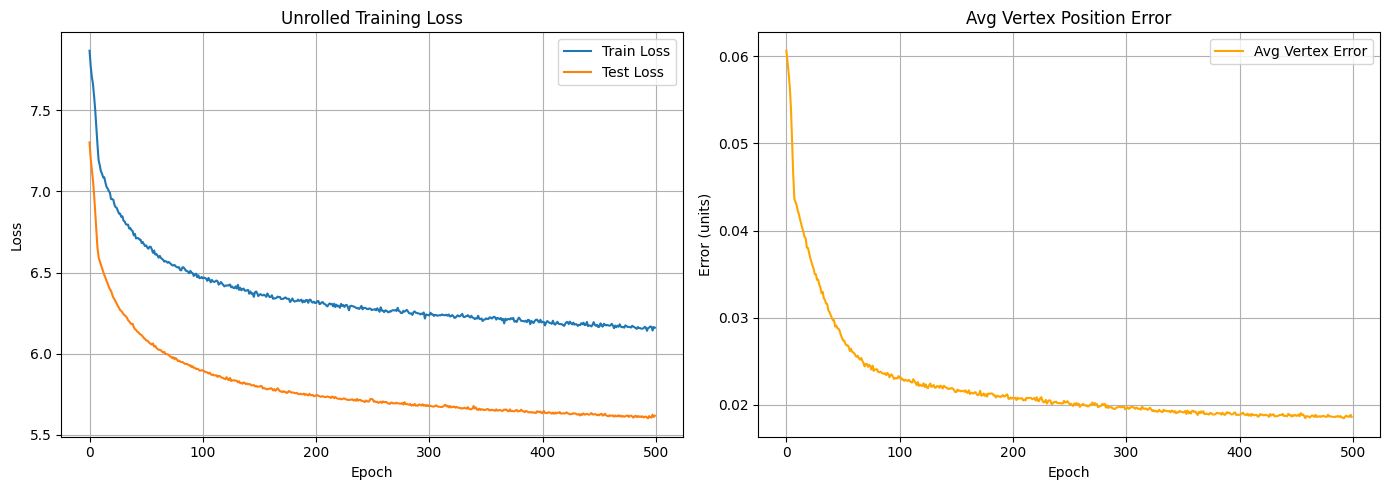

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train'], label='Train Loss')
axes[0].plot(history['test'],  label='Test Loss')
axes[0].set_title('Unrolled Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['vertex_error'], color='orange', label='Avg Vertex Error')
axes[1].set_title('Avg Vertex Position Error')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Error (units)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

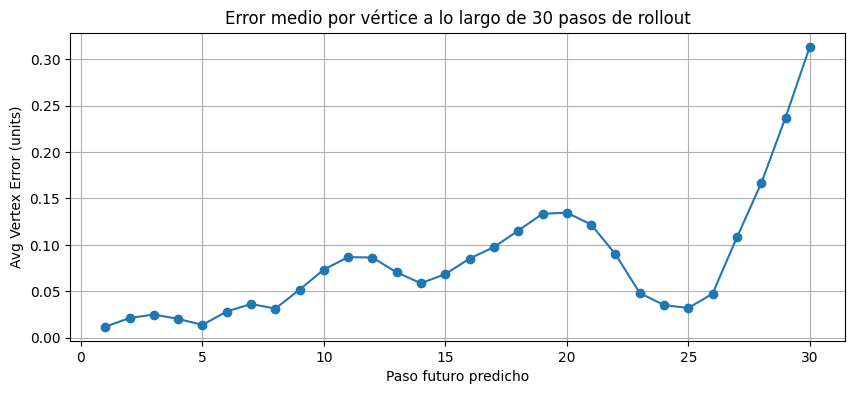

Si la curva crece lentamente → el unrolled training ha funcionado.
Si explota → prueba aumentar ROLLOUT_STEPS o NOISE_SIGMA.


In [10]:
# ─────────────────────────────────────────────────────────────────
# Evaluación del rollout autoregresivo completo sobre una secuencia
# ─────────────────────────────────────────────────────────────────
# Tomamos una secuencia de test y la predecimos N pasos hacia el futuro
# usando SOLO la historia inicial → comprobamos si el error se dispara

model.eval()
N_STEPS = 30  # cuántos pasos predecir en cadena

# Primer batch del test
seq_sample, future_sample = next(iter(test_loader))
seq_sample    = seq_sample[:1].float()     # solo 1 ejemplo
future_sample = future_sample[:1].float()

# Datos reales que seguirán (para comparar)
# Buscamos los siguientes N_STEPS frames desde el dataset
start_idx = train_size  # primer índice del test set
end_idx   = start_idx + SEQ_LEN + N_STEPS
real_sequence = data_tensor[start_idx:end_idx].unsqueeze(0).float()  # [1, SEQ+N, V, F]

rollout_preds = []   # posiciones predichas
rollout_reals = []   # posiciones reales

window = seq_sample.clone()  # [1, seq_len, V, F]

with torch.no_grad():
    for step in range(N_STEPS):
        window_norm  = norm_input(window)
        pred_dn      = model(window_norm)                        # [1, V, 3]
        last_pos     = window[:, -1, :, 0:3]
        pred_pos     = last_pos + denorm_delta(pred_dn)          # [1, V, 3]

        rollout_preds.append(pred_pos.squeeze(0).numpy())        # [V, 3]
        real_pos = real_sequence[:, SEQ_LEN + step, :, 0:3]
        rollout_reals.append(real_pos.squeeze(0).numpy())

        # Feedback: insertar predicción en la ventana
        new_frame = window[:, -1, :, :].clone()
        new_frame[:, :, 0:3] = pred_pos
        window = torch.cat([window[:, 1:, :, :], new_frame.unsqueeze(1)], dim=1)

# Error medio por vértice en cada paso del rollout
rollout_errors = [
    np.linalg.norm(rollout_preds[i] - rollout_reals[i], axis=-1).mean()
    for i in range(N_STEPS)
]

plt.figure(figsize=(10, 4))
plt.plot(range(1, N_STEPS+1), rollout_errors, marker='o')
plt.title(f'Error medio por vértice a lo largo de {N_STEPS} pasos de rollout')
plt.xlabel('Paso futuro predicho')
plt.ylabel('Avg Vertex Error (units)')
plt.grid(True)
plt.show()

print("Si la curva crece lentamente → el unrolled training ha funcionado.")
print("Si explota → prueba aumentar ROLLOUT_STEPS o NOISE_SIGMA.")

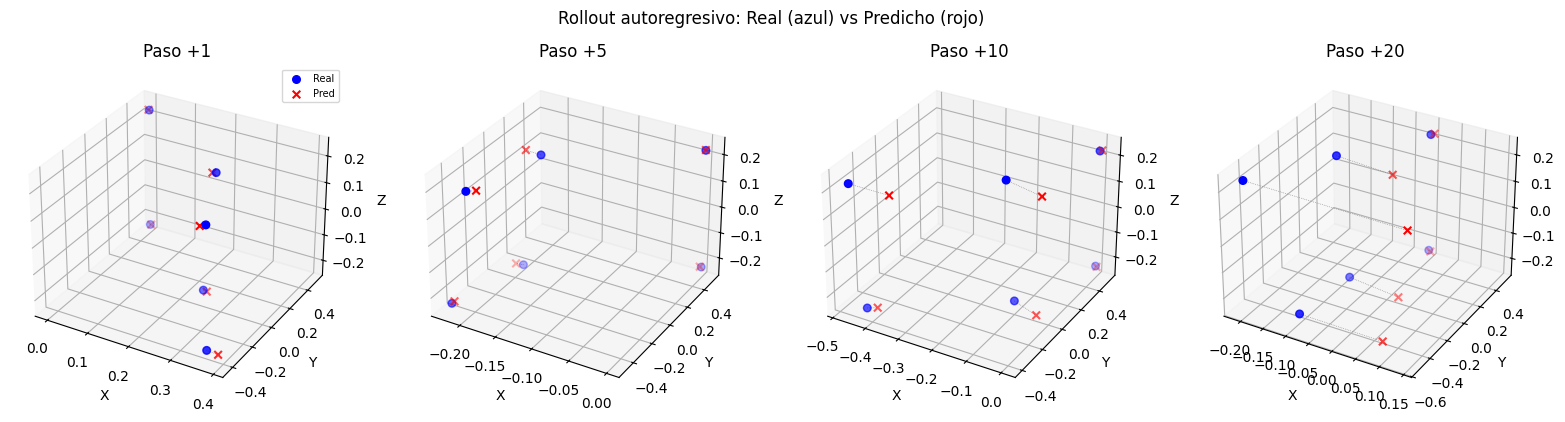

In [11]:
# ─────────────────────────────────────────────────────────────────
# Visualización 3D: shape real vs predicho en varios pasos futuros
# ─────────────────────────────────────────────────────────────────
steps_to_show = [0, 4, 9, 19]  # qué pasos visualizar
fig = plt.figure(figsize=(16, 4))

for col, step in enumerate(steps_to_show):
    ax = fig.add_subplot(1, len(steps_to_show), col+1, projection='3d')
    real = rollout_reals[step]
    pred = rollout_preds[step]

    ax.scatter(real[:, 0], real[:, 1], real[:, 2], c='blue',  s=30, label='Real',  marker='o')
    ax.scatter(pred[:, 0], pred[:, 1], pred[:, 2], c='red',   s=30, label='Pred',  marker='x')

    for i in range(num_vertices):
        ax.plot([real[i,0], pred[i,0]], [real[i,1], pred[i,1]],
                [real[i,2], pred[i,2]], color='gray', linestyle='dotted', linewidth=0.5)

    ax.set_title(f'Paso +{step+1}')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    if col == 0:
        ax.legend(fontsize=7)

plt.suptitle('Rollout autoregresivo: Real (azul) vs Predicho (rojo)', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Export a ONNX
*(Compatible con Unity — misma forma de entrada que rnn01)*

In [12]:
import torch
import onnx
import onnxruntime

model.eval()

# El modelo recibe exactamente la misma forma que rnn01
# [Batch=1, Seq_Len=5, Vertices=num_vertices, Features=num_features]
dummy_input = torch.randn(1, SEQ_LEN, num_vertices, num_features)

onnx_program = torch.onnx.export(
    model,
    dummy_input,
    "cloth_unrolled_rnn.onnx",
    export_params=True,
    opset_version=15,
    input_names=['input'],
    output_names=['output'],
)

# Verificar que el modelo ONNX es válido
onnx_model = onnx.load("cloth_unrolled_rnn.onnx")
onnx.checker.check_model(onnx_model)

# Test de inferencia con ONNXRuntime
ort_session = onnxruntime.InferenceSession("cloth_unrolled_rnn.onnx")
ort_out = ort_session.run(None, {'input': dummy_input.numpy()})
print(f"ONNX output shape: {ort_out[0].shape}")
print("Export exitoso — compatible con Unity Barracuda/Sentis.")

ONNX output shape: (1, 6, 3)
Export exitoso — compatible con Unity Barracuda/Sentis.


---
## Notas de tuning

| Hiperparámetro | Valor default | Qué hace si lo subes |
|---|---|---|
| `ROLLOUT_STEPS` | 8 | Más estabilidad a largo plazo, pero más VRAM y tiempo por paso |
| `NOISE_SIGMA` | 0.01 | Más robustez a errores de predicción acumulados |
| `VEL_WEIGHT` | 1.0 | Más énfasis en movimiento suave (menos jitter) |
| `HIDDEN_SIZE` | 128 | Más capacidad, más lento |

### Señales de que el unrolled training está funcionando
- El error de rollout (gráfica de pasos futuros) **crece lentamente** en lugar de explotar
- Las shapes 3D en pasos lejanos (+10, +20) siguen siendo reconocibles
- El train loss converge más despacio que rnn01 pero a un mínimo más robusto

### Si sigue siendo inestable
- Aumenta `ROLLOUT_STEPS` a 16 o 32
- Sube `NOISE_SIGMA` a 0.02 (como en el paper original)
- Reduce `lr` a `5e-5`
- Considera usar `GRUCell` en lugar de `RNNCell` para mejor memoria